In [66]:
import matplotlib.pyplot as plt
# from algorytm_obiektowo import Algorithm, SolutionHandler
import numpy as np
from random import sample
import os
import sys
from scipy import stats

# Pobranie katalogu, w którym znajduje się aktualny notatnik
notebook_dir = os.getcwd()
# Dodanie nadrzędnego katalogu do sys.path
deep_dir = os.path.join(notebook_dir, "Algorytm")
sys.path.append(deep_dir)

from algorytm_obiektowo import Algorithm, SolutionHandler

In [67]:
# opis testu
# Próba znalezienia średniej wielkości zmian wartości funkcji celu dla kolejnych rozwiązań podczas pracy algorytmu
# (O ile zmienia się średnio funkcja celu kiedy sobie skacze podczas pracy (ten wykres inny niż temperatury))
# 
# wywołanie algorytmu z sąsiedztwem s1 a następnie z s4 dla dużej startowej temperatuty T_init
# przejście przez f_change i wyliczenie różnic między wartościami w danej iteracji i najstępnej

In [68]:
# zmienne
list_of_number_of_items = [4,5,6]
gold_limit = 1000000
list_of_T_init = np.logspace(1,np.log10(50000),50) # np.linspace(10,50000,50)    # przedział <100,50000>
T_final = 1
list_of_alfa = [0.95, 0.99, 0.999]
list_of_main_chmaps = ['Fiora','Renekton', 'TwistedFate', 'Smolder']
list_of_enemy_champs = ['Samira', 'Trundle', 'Alistar', 'Corki', 'Ornn']
list_of_neighbourhoods = [[1],[2],[3],[4],[5],[6]]
list_of_item_names  = ['Abyssal Mask', 'Aether Wisp', 'Amplifying Tome', 'Anti-Tower Socks', "Archangel's Staff", 'Ardent Censer', 'Axiom Arc', 'B. F. Sword', "Bami's Cinder", 'Bandleglass Mirror', "Banshee's Veil", 'Base Turret Reinforced Armor (Turret Item)', "Berserker's Greaves", 'Black Cleaver', 'Black Spear', 'Blackfire Torch', 'Blade of the Ruined King', 'Blasting Wand', 'Blighting Jewel', 'Bloodsong', 'Bloodthirster', 'Boots', 'Boots of Swiftness', 'Bounty of Worlds', 'Bramble Vest', 'Cappa Juice', 'Catalyst of Aeons', "Caulfield's Warhammer", 'Celestial Opposition', 'Chain Vest', 'Chempunk Chainsword', 'Cloak of Agility', 'Cloth Armor', 'Control Ward', 'Cosmic Drive', 'Cryptbloom', 'Crystalline Bracer', 'Cull', 'Dagger', 'Dark Seal', 'Dawncore', "Dead Man's Plate", "Death's Dance", "Death's Daughter", "Doran's Blade", "Doran's Ring", "Doran's Shield", 'Dream Maker', 'Echoes of Helia', 'Eclipse', 'Edge of Night', 'Elixir of Avarice', 'Elixir of Force', 'Elixir of Iron', 'Elixir of Skill', 'Elixir of Sorcery', 'Elixir of Wrath', 'Essence Reaver', "Executioner's Calling", 'Experimental Hexplate', 'Eye of the Herald', 'Faerie Charm', 'Farsight Alteration', 'Fated Ashes', 'Fiendish Codex', 'Fimbulwinter', 'Fire at Will', 'Forbidden Idol', 'Force of Nature', 'Fortification', 'Frozen Heart', "Giant's Belt", 'Glacial Buckler', 'Glowing Mote', 'Guardian Angel', "Guardian's Blade", "Guardian's Hammer", "Guardian's Horn", "Guardian's Orb", "Guinsoo's Rageblade", 'Gusto', 'Gustwalker Hatchling', 'Haunting Guise', 'Health Potion', 'Hearthbound Axe', 'Heartsteel', 'Hexdrinker', 'Hextech Alternator', 'Hextech Rocketbelt', 'Hollow Radiance', 'Horizon Focus', 'Hubris', 'Hullbreaker', 'Iceborn Gauntlet', 'Immortal Shieldbow', 'Imperial Mandate', 'Infinity Edge', 'Ionian Boots of Lucidity', "Jak'Sho, The Protean", 'Kaenic Rookern', 'Kindlegem', "Knight's Vow", 'Kraken Slayer', 'Last Whisper', "Liandry's Torment", 'Lich Bane', 'Locket of the Iron Solari', 'Long Sword', "Lord Dominik's Regards", 'Lost Chapter', "Luden's Companion", 'Malignance', 'Manamune', 'Maw of Malmortius', "Mejai's Soulstealer", 'Mercurial Scimitar', "Mercury's Treads", "Mikael's Blessing", 'Moonstone Renewer', 'Morellonomicon', 'Mortal Reminder', 'Mosstomper Seedling', 'Muramana', "Nashor's Tooth", 'Navori Flickerblade', 'Needlessly Large Rod', 'Negatron Cloak', 'Noonquiver', 'Null-Magic Mantle', 'Oblivion Orb', 'Ohmwrecker (Turret Item)', 'Opportunity', 'Oracle Lens', 'Overcharged', "Overlord's Bloodmail", 'Phage', 'Phantom Dancer', 'Phreakish Gusto', 'Pickaxe', 'Plated Steelcaps', 'Poro-Snax', 'Profane Hydra', 'Quicksilver Sash', "Rabadon's Deathcap", 'Raise Morale', "Randuin's Omen", 'Rapid Firecannon', 'Ravenous Hydra', 'Rectrix', 'Recurve Bow', 'Redemption', 'Refillable Potion', 'Reinforced Armor (Turret Item)', 'Rejuvenation Bead', 'Riftmaker', 'Rod of Ages', 'Ruby Crystal', "Runaan's Hurricane", 'Runic Compass', "Rylai's Crystal Scepter", 'Sapphire Crystal', 'Scarecrow Effigy', 'Scorchclaw Pup', "Scout's Slingshot", "Seeker's Armguard", "Seraph's Embrace", "Serpent's Fang", 'Serrated Dirk', "Serylda's Grudge", 'Shadowflame', 'Shattered Armguard', 'Sheen', "Shurelya's Battlesong", 'Slightly Magical Boots', 'Solstice Sleigh', "Sorcerer's Shoes", 'Spear of Shojin', "Spectre's Cowl", 'Spirit Visage', 'Staff of Flowing Water', 'Statikk Shiv', 'Stealth Ward', 'Steel Sigil', "Sterak's Gage", 'Stormsurge', 'Stridebreaker', 'Sundered Sky', 'Sunfire Aegis', 'Super Mech Armor', 'Super Mech Power Field', 'Symbiotic Soles', 'Synchronized Souls', 'Tear of the Goddess', 'Terminus', 'The Brutalizer', 'The Collector', 'Thornmail', 'Tiamat', 'Titanic Hydra', 'Total Biscuit of Everlasting Will', 'Trailblazer', 'Trinity Force', 'Tunneler', 'Turret Plating', 'Umbral Glaive', 'Unending Despair', 'Vampiric Scepter', 'Verdant Barrier', 'Vigilant Wardstone', 'Void Staff', 'Voltaic Cyclosword', "Warden's Eye", "Warden's Mail", "Warmog's Armor", 'Watchful Wardstone', 'Winged Moonplate', "Winter's Approach", "Wit's End", 'World Atlas', "Youmuu's Ghostblade", 'Your Cut', 'Yun Tal Wildarrows', "Zaz'Zak's Realmspike", 'Zeal', "Zeke's Convergence", 'Zephyr', "Zhonya's Hourglass"]
# random_start_items =sample(list_of_item_names,list_of_number_of_items[2])
random_start_items = ["Banshee's Veil","Giant's Belt",'Watchful Wardstone','Vigilant Wardstone','Morellonomicon','Total Biscuit of Everlasting Will']

In [69]:
# zmienne do przechowywania wyników
diffs_in_f_ = []
normal_distr_of_diff = []

In [70]:
# obliczenia
alg = Algorithm()
alg.set_no_of_items(list_of_number_of_items[2])
alg.gold_setting(gold_limit)
alg.starting_enemy_parameters(list_of_enemy_champs)

handler: SolutionHandler = alg.simulated_annealing(list_of_main_chmaps[2],random_start_items,list_of_neighbourhoods[1],\
                                                   list_of_T_init[-1],T_final,list_of_alfa[1],list_of_enemy_champs)

for i in range(1,handler.number_of_iterations):
    d = handler.f_change[i-1] - handler.f_change[i]
    if d < 0:
        diffs_in_f_.append(abs(d))

# diffs_in_f_.sort(reverse=True)


mean_diff = np.mean(diffs_in_f_)

In [71]:
mean_diff


187.10546901687502

In [72]:
np.where(np.isclose(diffs_in_f_,mean_diff,rtol=0.1))

(array([  5,  13,  32,  39, 107, 108, 157, 158, 164, 211, 218], dtype=int64),)

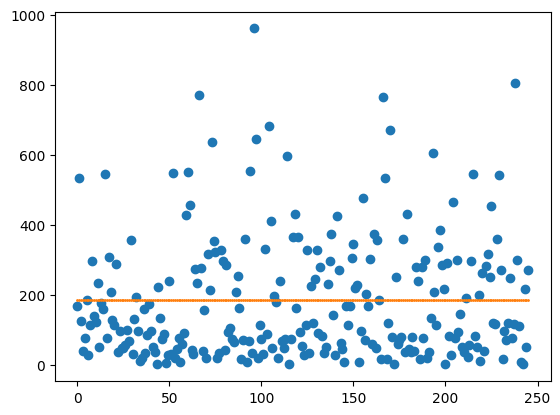

In [76]:
# wykres
plt.scatter(range(len(diffs_in_f_)),diffs_in_f_)
plt.scatter(range(len(diffs_in_f_)), np.ones(len(diffs_in_f_))*mean_diff,s=1)

# plt.plot(my_dict.keys(),my_dict.values())
# plt.scatter(95,mean_diff)
plt.title("Wykres wielkości różnic ")
plt.ylabel("")

plt.show()

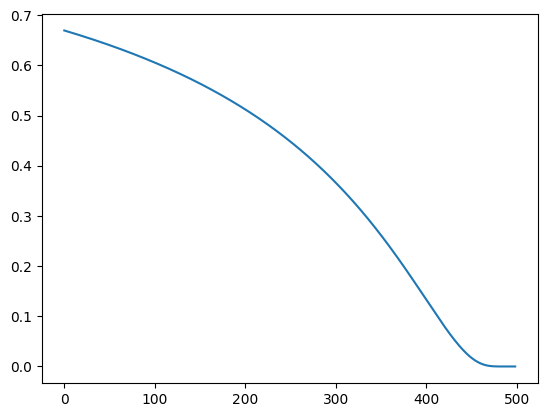

In [78]:
# inne testy
T = np.arange(1,500,1)
T = np.flip(T)
diff = -200
x = (diff/T)
plt.plot(np.exp(x))
plt.show()